In [1]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device.rp_125_14_z7010 import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame
from redpitaya_io_sync.io.scope import ScopeSource
from redpitaya_io_sync.serial.spi import SPI


### Device instances

In [2]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

### IO Sequences & IO Frames instances

In [3]:
seq = IoSequence(device_list=[rp_0])
fr_0 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_1 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_2 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_3 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)

### Frame definitions 


In [ ]:
#FRAME O-3 (cpha=0-1, cpol=0-1)

for fr, cpol, cpha in zip([fr_0, fr_1, fr_2, fr_3], [0, 0, 1, 1], [0, 1, 0, 1]):
    spi = SPI(io = fr.digital_io_2, clk_div= 8, cpol=cpol, cpha=cpha)

    fr.reset()
    spi.io_config()
    fr.scope_1.source(ScopeSource.DIGITAL_IO_2)
    fr.scope_1.decimation(1)
    fr.wait(100)
    fr.rsync()

    fr.scope_1.acquire(128)
    fr.wait(16)
    spi.cs_low()
    spi.transfer(data=0b10110010, size=8)
    spi.cs_high()


### Sequence definition

In [5]:
seq.reset()
for fr, cpol, cpha in zip([fr_0, fr_1, fr_2, fr_3], [0, 0, 1, 1], [0, 1, 0, 1]):
    seq.add_frame(frame=fr, device=rp_0, label=f"cpol={cpol} cpha={cpha}")

print(seq.sequence_description())

+--------------------+
| rp_0@192.168.1.143 |
+--------------------+
| cpol=0 cpha=0      |
| cpol=0 cpha=1      |
| cpol=1 cpha=0      |
| cpol=1 cpha=1      |
+--------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Upload & Run sequence

In [6]:
seq.upload(force=False)
seq.start()
while not seq.is_done():
    if seq.is_error():
        print("Sequence error. Please check status.")
        break
    time.sleep(0.01)


In [7]:
seq.get_status()

{'rp_0@192.168.1.143': {'enabled': True,
  'done': True,
  'error': False,
  'current_frame': 'cpol=1 cpha=1',
  'io': {'rf_out_1': {'error': False, 'done': True},
   'rf_out_2': {'error': False, 'done': True},
   'digital_io_1': {'error': False, 'done': True},
   'digital_io_2': {'error': False, 'done': True},
   'digital_io_3': {'error': False, 'done': True},
   'digital_io_4': {'error': False, 'done': True},
   'analog_out_1': {'error': False, 'done': True},
   'analog_out_2': {'error': False, 'done': True},
   'analog_out_3': {'error': False, 'done': True},
   'analog_out_4': {'error': False, 'done': True},
   'scope_1': {'error': False, 'done': True},
   'scope_2': {'error': False, 'done': True},
   'led': {'error': False, 'done': True}}}}

In [8]:
seq.stop()

### Plot acquisitions

Device: rp_0@192.168.1.143
Frame: cpol=0 cpha=0
Acquisition: acq_0 (t=102, dec=1, samples=128)


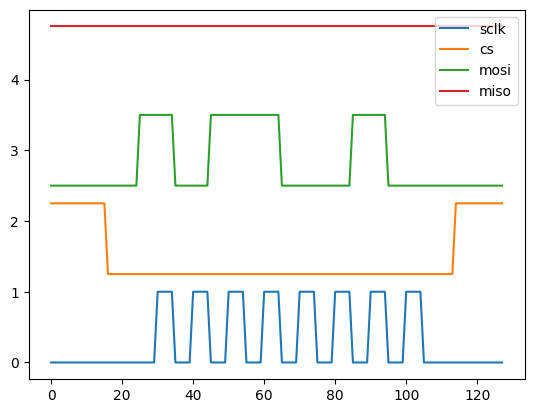

Device: rp_0@192.168.1.143
Frame: cpol=0 cpha=1
Acquisition: acq_0 (t=102, dec=1, samples=128)


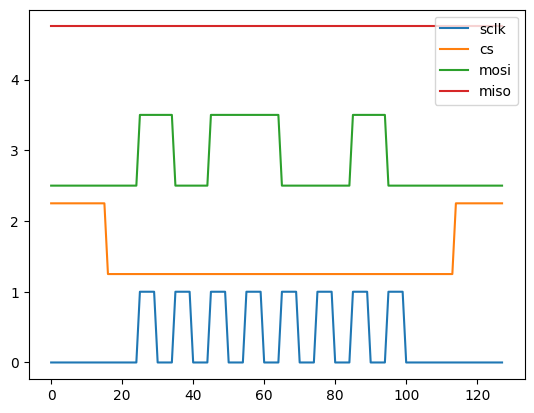

Device: rp_0@192.168.1.143
Frame: cpol=1 cpha=0
Acquisition: acq_0 (t=102, dec=1, samples=128)


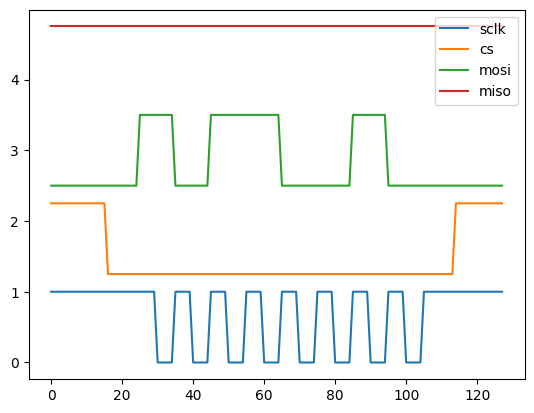

Device: rp_0@192.168.1.143
Frame: cpol=1 cpha=1
Acquisition: acq_0 (t=102, dec=1, samples=128)


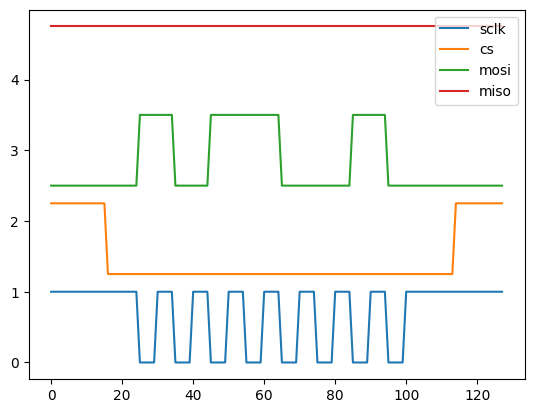

In [9]:
scope_dict = seq.get_scope()

for device_id in scope_dict.keys():
    for frame_label in scope_dict[device_id].keys():
        for scope_label in scope_dict[device_id][frame_label].keys():
            for acq_label in scope_dict[device_id][frame_label][scope_label].keys():
                t = scope_dict[device_id][frame_label][scope_label][acq_label]["t"]
                dec = scope_dict[device_id][frame_label][scope_label][acq_label]["dec"]
                samples = scope_dict[device_id][frame_label][scope_label][acq_label]["samples"]
                data = scope_dict[device_id][frame_label][scope_label][acq_label]["data"]
                print(f"Device: {device_id}")
                print(f"Frame: {frame_label}")
                print(f"Acquisition: {acq_label} (t={t}, dec={dec}, samples={samples})")
                plt.figure()
                plt.plot(np.bitwise_and(np.right_shift(data, 0), 1), label="sclk")
                plt.plot(1.25 + np.bitwise_and(np.right_shift(data, 1), 1), label="cs")
                plt.plot(2.5 + np.bitwise_and(np.right_shift(data, 2), 1), label="mosi")
                plt.plot(3.75 + np.bitwise_and(np.right_shift(data, 3), 1), label="miso")
                plt.legend(loc=1)
                plt.show()
